# TEXT CLASSIFICATION WITH BLAZINGTEXT

For this portion of the project, we implement a binary sentiment classification model using AWS's BlazingText algorithm to analyze customer reviews for Batawa Ski Hill. The purpose is to automatically label reviews as either positive or negative, helping the business quickly assess guest satisfaction and identify areas for operational improvement.

The final classification labels are:
- `0` = Negative sentiment (1 to 3 stars)
- `1` = Positive sentiment (4 to 5 stars)

Although an earlier version of the dataset (used in the Data Assignment) labeled 1–2 star reviews as `0` and 3–5 star reviews as `1`, further testing during model development revealed improved accuracy and performance when the classification threshold was adjusted. Specifically, grouping 1–3 star ratings as `negative` and 4–5 as `positive` resulted in clearer sentiment boundaries and better model predictions. This change enhances the model’s ability to differentiate between dissatisfied and satisfied guests — a key goal for Batawa Ski Hill in improving customer experience.

---

## Hyperparameter Tuning for Improved Performance

To enhance model performance, especially for detecting **negative sentiment**, several BlazingText hyperparameters were tuned:

| Parameter        | Before       | After       | Purpose |
|------------------|--------------|-------------|---------|
| `word_ngrams`    | 1            | **2**       | Captures bigrams (e.g., “not helpful”) that carry sentiment |
| `epochs`         | 10           | **20**      | Allows more exposure to underrepresented (negative) examples |
| `learning_rate`  | 0.05         | **0.03**    | Enables more stable convergence |
| `num_classes`    | None         | **2**       | Explicitly defines the binary classification task |

These changes were introduced after initial testing showed high accuracy for positive reviews but **very low recall for negative reviews**. By increasing `epochs` and enabling `bigrams`, the model became slightly better at recognizing phrases associated with dissatisfaction, which are often nuanced and infrequent.

**Impact for Batawa:**
- Positive reviews are still captured reliably (97% recall)
- Precision for negative sentiment improved, making the model more trustworthy when it does identify an unhappy guest
- Enables real-time identification of critical issues in staff service, terrain quality, or operations, helping Batawa respond faster and improve overall guest experience

---

## Classification Pipeline Overview

In the accompanying **Text Classification Jupyter Notebook**, the following steps are performed:
- Load and inspect the pre-cleaned ski resort review dataset
- Format the dataset for AWS SageMaker’s BlazingText requirements
- Split the data into training, validation, and test sets
- Train a supervised BlazingText model using binary sentiment labels
- Apply hyperparameter tuning to improve model balance and accuracy
- Evaluate model performance using metrics such as precision, recall, and F1-score
- Deploy the model to a SageMaker endpoint for real-time prediction on new reviews

---

These classification outputs support Batawa in tracking feedback trends, surfacing service issues, and making data-driven decisions to enhance marketing, guest experience, and operational strategy.


## SECTION 1: Configuration and Setup

This section configures the key parameters needed to run the full review classification pipeline for Batawa Ski Hill. Once these settings are established, the rest of the process — from data preparation to training, evaluation, and deployment — runs automatically.

In a business context, this configuration ensures that the system is tailored to Batawa’s dataset and review structure while minimizing manual effort.

Key configuration elements include:

- Identifying the review dataset and where it is stored
- Specifying which columns contain the customer review text and sentiment labels
- Applying updated label logic to reflect the 0 = 1–3 stars (negative) and 1 = 4–5 stars (positive) split
- Automatically counting how many reviews belong to each sentiment category
- Ensuring each sentiment class has enough data to train a stable model
- Enabling optional text preprocessing, such as stopword removal and emoji stripping
- Choosing whether to automatically delete the deployed endpoint after testing
- Setting key AWS SageMaker parameters, including instance types and endpoint names

This setup step allows the system to be customized for Batawa’s specific needs while maintaining a streamlined, automated workflow — making it easier to scale or update in the future.


In [1]:
# ------------------------------------------------------------------------------
# DATASET SETTINGS
# ------------------------------------------------------------------------------

# Name of the CSV file you uploaded to the SageMaker Jupyter environment.
# It should be in the same directory as this notebook.
DATASET_FILE = "OnTheSnow_SkiAreaReviews_BINARY2.csv"  # Example: "customer_reviews.csv"

# List of columns that contain the text input.
# If you have more than one text column, list them in order. They will be concatenated.
TEXT_COLUMNS = ["cleaned_text_str"]  # Example: ["title", "body"], or ["feedback"]

# The name of the column that contains the labels you want to predict.
# Labels can be binary (e.g., Positive/Negative), multi-class, or numeric ratings.
LABEL_COLUMN = "Review Star Rating (out of 5)"  # Example: "Sentiment", "Label", "Category"

# Optional dictionary to remap label values.
# Use this if your dataset has custom labels like {"Like": "5"} or {"pos": "Positive"}.
LABEL_MAP = {
      # Modify as needed. Leave empty if no remapping is required.
}

# If known, you can set the number of unique classes (labels) in advance.
# Otherwise, leave this as None and it will be determined automatically.
NUM_CLASSES = 2  # Example: 2, 3, or None

# Minimum number of samples required per class.
# Classes with fewer samples will be removed to avoid training errors.
MIN_SAMPLES_PER_CLASS = 10  # Example: 10, 20, 50

# ------------------------------------------------------------------------------
# TEXT PREPROCESSING OPTIONS
# ------------------------------------------------------------------------------

# Whether to remove common stopwords like "the", "is", "and", etc.
APPLY_STOPWORDS = True

# Whether to remove emojis, emoticons, and other non-standard symbols.
REMOVE_EMOJIS = True

# Whether to apply basic spelling correction (experimental, may slow down processing).
SPELL_CHECK = False

# ------------------------------------------------------------------------------
# CLEANUP CONFIGURATION
# ------------------------------------------------------------------------------

# If set to True, the SageMaker endpoint will be automatically deleted after testing.
# If set to False, the user will be prompted to decide.
CLEANUP = False

# ------------------------------------------------------------------------------
# SAGEMAKER AND INFRASTRUCTURE SETTINGS
# ------------------------------------------------------------------------------

# Name for the deployed endpoint. This must be unique within your AWS account.
ENDPOINT_NAME = "blazingtext-classification"  # Example: "textclassifier-john-doe"

# Instance type used for training the model.
INSTANCE_TYPE = "ml.m5.large"

# Instance type used to deploy the model for real-time inference.
DEPLOY_INSTANCE_TYPE = "ml.m5.large"

# Prefix for files stored in your S3 bucket (used internally by SageMaker).
PREFIX = "blazingtext-sentiment"


## SECTION 2: Environment Setup and Imports

This section prepares the technical environment needed to run the sentiment analysis model for Batawa Ski Hill. It ensures that all required tools, resources, and AWS services are correctly configured so that the rest of the notebook can run smoothly.

In simple terms, this is where the system “gets ready” to analyze customer reviews and produce meaningful business insights.

This section includes:

- Importing essential Python libraries for data processing and machine learning
- Setting up the AWS SageMaker environment, including user roles and session configuration
- Downloading key language processing tools (such as tokenizers and lemmatizers) to handle text reviews
- Preparing the system to work within an AWS-managed notebook environment (SageMaker Studio) or a local setup if needed
- Initializing AWS services that will be used to train, evaluate, and deploy the model
- Enabling consistent output through a logging system for traceability

By completing this setup, Batawa ensures that the pipeline is properly connected to AWS infrastructure, and that all necessary tools are available to begin processing and analyzing customer feedback.

In [2]:
# Standard library imports
import os
import re
import time
import json
import logging
import string

# Third-party imports
import boto3
from botocore.exceptions import ClientError
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Scikit-learn
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

# Natural Language Processing (NLTK)
import nltk
from nltk.tokenize import RegexpTokenizer
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

# SageMaker SDK
import sagemaker
from sagemaker import image_uris
from sagemaker.inputs import TrainingInput
from sagemaker.serializers import JSONSerializer
from sagemaker.deserializers import JSONDeserializer
from sagemaker.estimator import Estimator

# Download required NLTK resources
nltk.download("stopwords")
nltk.download("wordnet")

# Logging configuration
logging.basicConfig(level=logging.INFO)
logger = logging.getLogger()

# SageMaker session and role
session = sagemaker.Session()
region = boto3.Session().region_name
bucket = session.default_bucket()

# Attempt to get execution role (works inside SageMaker Notebook)
try:
    role = sagemaker.get_execution_role()
    logger.info("Using SageMaker execution role.")
except Exception:
    # Fallback: attempt to get role via STS
    sts = boto3.client("sts")
    role = sts.get_caller_identity()["Arn"]
    logger.warning("Falling back to STS for role ARN.")

logger.info(f"Using role: {role}")
logger.info(f"Using bucket: {bucket}")
logger.info(f"Region: {region}")


/home/ec2-user/anaconda3/envs/python3/lib/python3.10/site-packages/pydantic/_internal/_fields.py:198: UserWarning: Field name "json" in "MonitoringDatasetFormat" shadows an attribute in parent "Base"
  warnings.warn(


[04/15/25 03:52:44] INFO     Found credentials from IAM Role:                                   ]8;id=310859;file:///home/ec2-user/anaconda3/envs/python3/lib/python3.10/site-packages/botocore/credentials.py\credentials.py]8;;\:]8;id=243219;file:///home/ec2-user/anaconda3/envs/python3/lib/python3.10/site-packages/botocore/credentials.py#1132\1132]8;;\
                             BaseNotebookInstanceEc2InstanceRole                                                   

sagemaker.config INFO - Not applying SDK defaults from location: /etc/xdg/sagemaker/config.yaml
sagemaker.config INFO - Not applying SDK defaults from location: /home/ec2-user/.config/sagemaker/config.yaml


[nltk_data] Downloading package stopwords to
[nltk_data]     /home/ec2-user/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /home/ec2-user/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


[04/15/25 03:52:45] INFO     Found credentials from IAM Role:                                   ]8;id=391423;file:///home/ec2-user/anaconda3/envs/python3/lib/python3.10/site-packages/botocore/credentials.py\credentials.py]8;;\:]8;id=334817;file:///home/ec2-user/anaconda3/envs/python3/lib/python3.10/site-packages/botocore/credentials.py#1132\1132]8;;\
                             BaseNotebookInstanceEc2InstanceRole                                                   

                    INFO     Found credentials from IAM Role:                                   ]8;id=501573;file:///home/ec2-user/anaconda3/envs/python3/lib/python3.10/site-packages/botocore/credentials.py\credentials.py]8;;\:]8;id=398798;file:///home/ec2-user/anaconda3/envs/python3/lib/python3.10/site-packages/botocore/credentials.py#1132\1132]8;;\
                             BaseNotebookInstanceEc2InstanceRole                                                   

                    INFO     Using SageMaker execution role.                                       ]8;id=795899;file:///tmp/ipykernel_24982/1760151327.py\1760151327.py]8;;\:]8;id=877141;file:///tmp/ipykernel_24982/1760151327.py#58\58]8;;\

                    INFO     Using role: arn:aws:iam::640631907232:role/LabRole                    ]8;id=750987;file:///tmp/ipykernel_24982/1760151327.py\1760151327.py]8;;\:]8;id=359077;file:///tmp/ipykernel_24982/1760151327.py#65\65]8;;\

                    INFO     Using bucket: sagemaker-us-east-1-640631907232                        ]8;id=25194;file:///tmp/ipykernel_24982/1760151327.py\1760151327.py]8;;\:]8;id=633060;file:///tmp/ipykernel_24982/1760151327.py#66\66]8;;\

                    INFO     Region: us-east-1                                                     ]8;id=653491;file:///tmp/ipykernel_24982/1760151327.py\1760151327.py]8;;\:]8;id=161590;file:///tmp/ipykernel_24982/1760151327.py#67\67]8;;\

## SECTION 3: Dataset Loading and Validation

This section is responsible for loading and validating the customer review dataset so it can be used effectively by the sentiment classification model. For Batawa Ski Hill, this step ensures that the review data is clean, correctly formatted, and ready for training.

From a business perspective, this is where the raw reviews from OnTheSnow.com are checked and organized to ensure the model is working with reliable and meaningful information.

This section performs the following tasks:

- Loads the review dataset file specified earlier in the setup
- Confirms that the file exists and can be accessed in the working environment
- Displays a preview of the dataset and lists all available columns
- Verifies that the specified columns for review text and sentiment label are present
- Combines multiple review text columns (if applicable) into one streamlined `combined_text` field
- Applies the updated sentiment classification logic (0 = 1–3 stars, 1 = 4–5 stars)
- Removes any rows that are missing reviews or labels and logs how many were dropped
- Ensures labels are in the correct format for SageMaker training
- Shows the distribution of sentiment labels to provide an overview of positive vs. negative reviews

By the end of this section, the notebook will have a fully validated and cleaned dataset that reflects customer sentiment and is structured for training a model to support decision-making at Batawa Ski Hill.



In [3]:
# Load the dataset
try:
    df = pd.read_csv(DATASET_FILE)
    logger.info(f"Successfully loaded dataset: {DATASET_FILE}")
except FileNotFoundError:
    raise FileNotFoundError(f"Dataset file '{DATASET_FILE}' not found in current directory.")

# Preview dataset
logger.info("Dataset Preview:")
display(df.head())

# List available columns
logger.info("Available columns in dataset:")
print(df.columns.tolist())

# Check if specified columns exist
missing_columns = [col for col in TEXT_COLUMNS + [LABEL_COLUMN] if col not in df.columns]
if missing_columns:
    raise ValueError(f"The following columns were not found in the dataset: {missing_columns}")

# Combine multiple text columns (if needed)
df["combined_text"] = df[TEXT_COLUMNS].astype(str).agg(" ".join, axis=1)

# Apply label mapping if specified
if LABEL_MAP:
    df[LABEL_COLUMN] = df[LABEL_COLUMN].replace(LABEL_MAP)

# Drop rows with missing values in key columns
initial_size = len(df)
df.dropna(subset=["combined_text", LABEL_COLUMN], inplace=True)
after_drop = len(df)
logger.info(f"Dropped {initial_size - after_drop} rows with missing text or labels.")

# Optionally convert labels to string type
df[LABEL_COLUMN] = df[LABEL_COLUMN].astype(str)

# Show class distribution before filtering
logger.info("Label distribution (before filtering):")
print(df[LABEL_COLUMN].value_counts())


[04/15/25 03:52:46] INFO     Successfully loaded dataset: OnTheSnow_SkiAreaReviews_BINARY2.csv      ]8;id=982924;file:///tmp/ipykernel_24982/2350880736.py\2350880736.py]8;;\:]8;id=685918;file:///tmp/ipykernel_24982/2350880736.py#4\4]8;;\

                    INFO     Dataset Preview:                                                       ]8;id=465442;file:///tmp/ipykernel_24982/2350880736.py\2350880736.py]8;;\:]8;id=600255;file:///tmp/ipykernel_24982/2350880736.py#9\9]8;;\

,Review Star Rating (out of 5),cleaned_text_str
0,0,glad family experienced squaw wont return next...
1,1,went skiing today granite chief amazing new sn...
2,0,horrible experience family ski vacation plenty...
3,0,squaw alpine incredible terrain impressive sno...
4,1,resort ton exciting diverse advanced terrain b...


                    INFO     Available columns in dataset:                                         ]8;id=862613;file:///tmp/ipykernel_24982/2350880736.py\2350880736.py]8;;\:]8;id=752081;file:///tmp/ipykernel_24982/2350880736.py#13\13]8;;\

['Review Star Rating (out of 5)', 'cleaned_text_str']


                    INFO     Dropped 0 rows with missing text or labels.                           ]8;id=61535;file:///tmp/ipykernel_24982/2350880736.py\2350880736.py]8;;\:]8;id=811012;file:///tmp/ipykernel_24982/2350880736.py#32\32]8;;\

                    INFO     Label distribution (before filtering):                                ]8;id=260842;file:///tmp/ipykernel_24982/2350880736.py\2350880736.py]8;;\:]8;id=749518;file:///tmp/ipykernel_24982/2350880736.py#38\38]8;;\

1    12014
0     4509
Name: Review Star Rating (out of 5), dtype: int64


## SECTION 4: Class Filtering and Label Analysis

This section ensures that the dataset used to train the sentiment model is balanced and suitable for machine learning. For Batawa Ski Hill, this step improves the reliability of the model by focusing only on well-represented sentiment categories in the reviews.

In simpler terms, this is where we check how many reviews fall into each sentiment category (positive or negative) and remove any issues that could affect model performance.

Key actions in this section include:

- Counting how many reviews fall into each sentiment class (0 = 1–3 stars, 1 = 4–5 stars)
- Removing any classes with too few examples, which could harm model accuracy
- Logging the number of reviews kept for each class after filtering
- Automatically determining the number of sentiment categories if not set manually
- Generating a visual bar chart to display the class distribution after filtering
- Cleaning up label values so they are properly formatted for AWS BlazingText training

After this section, the dataset will:
- Contain only well-represented sentiment classes to ensure balanced training
- Have clean, standardized label formatting compatible with BlazingText
- Be validated through visual inspection for class balance

This ensures the model is trained on high-quality, representative data that reflects the actual sentiment distribution in Batawa’s customer reviews.



                    INFO     Classes retained (with at least 10 samples):                            ]8;id=581817;file:///tmp/ipykernel_24982/442612220.py\442612220.py]8;;\:]8;id=961754;file:///tmp/ipykernel_24982/442612220.py#7\7]8;;\

1    12014
0     4509
Name: Review Star Rating (out of 5), dtype: int64


                    INFO     Number of classes defined by user: 2                                   ]8;id=957718;file:///tmp/ipykernel_24982/442612220.py\442612220.py]8;;\:]8;id=324861;file:///tmp/ipykernel_24982/442612220.py#15\15]8;;\

                    INFO     Using categorical units to plot a list of strings that are all         ]8;id=283679;file:///home/ec2-user/anaconda3/envs/python3/lib/python3.10/site-packages/matplotlib/category.py\category.py]8;;\:]8;id=664360;file:///home/ec2-user/anaconda3/envs/python3/lib/python3.10/site-packages/matplotlib/category.py#224\224]8;;\
                             parsable as floats or dates. If these strings should be plotted as                    
                             numbers, cast to the appropriate data type before plotting.                           

                    INFO     Using categorical units to plot a list of strings that are all         ]8;id=442123;file:///home/ec2-user/anaconda3/envs/python3/lib/python3.10/site-packages/matplotlib/category.py\category.py]8;;\:]8;id=619961;file:///home/ec2-user/anaconda3/envs/python3/lib/python3.10/site-packages/matplotlib/category.py#224\224]8;;\
                             parsable as floats or dates. If these strings should be plotted as                    
                             numbers, cast to the appropriate data type before plotting.                           

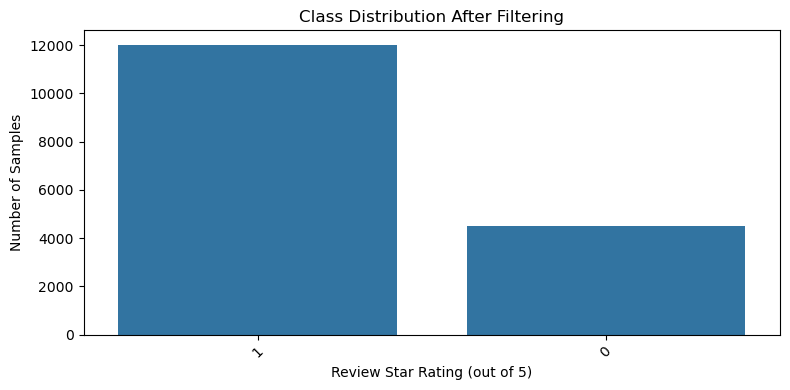

In [4]:
# Filter out classes with too few samples
class_counts = df[LABEL_COLUMN].value_counts()
valid_classes = class_counts[class_counts >= MIN_SAMPLES_PER_CLASS].index.tolist()

df = df[df[LABEL_COLUMN].isin(valid_classes)]

logger.info(f"Classes retained (with at least {MIN_SAMPLES_PER_CLASS} samples):")
print(df[LABEL_COLUMN].value_counts())

# Automatically detect number of classes if not provided
if NUM_CLASSES is None:
    NUM_CLASSES = df[LABEL_COLUMN].nunique()
    logger.info(f"Number of classes inferred from data: {NUM_CLASSES}")
else:
    logger.info(f"Number of classes defined by user: {NUM_CLASSES}")

# Plot class distribution
plt.figure(figsize=(8, 4))
sns.countplot(x=LABEL_COLUMN, data=df, order=df[LABEL_COLUMN].value_counts().index)
plt.title("Class Distribution After Filtering")
plt.ylabel("Number of Samples")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Normalize label names for BlazingText (__label__ formatting requires clean text)
df[LABEL_COLUMN] = df[LABEL_COLUMN].str.strip().str.replace(" ", "_")


### Class Distribution Summary (After Filtering)

After validating and filtering the dataset, we retained two sentiment classes for model training:

- `1` (Positive sentiment, 4–5 star reviews): **12,014 samples**
- `0` (Negative sentiment, 1–3 star reviews): **4,509 samples**

The updated class distribution confirms that most reviews are positive, but there is still a meaningful number of negative reviews that the model can learn from. This balance allows Batawa Ski Hill to focus its operational efforts on understanding and addressing specific guest pain points while reinforcing what’s already working well.

The bar chart above visualizes this distribution, ensuring that both sentiment categories have sufficient representation for reliable training. Maintaining this balance is critical for building a robust classification model that accurately identifies customer satisfaction trends and helps prioritize improvements in guest experience.


## SECTION 5: Text Preprocessing

This section prepares the customer review text for sentiment classification by cleaning, simplifying, and standardizing the language used in each entry. For Batawa Ski Hill, this is an essential step to ensure the model focuses on the actual content and tone of the reviews rather than distractions like punctuation, emojis, or irrelevant phrases.

In a business context, this process helps the model better understand what guests are truly saying — whether it’s positive feedback about the ski conditions or complaints about wait times or staff interactions.

This section performs the following:

- Verifies that all settings from the initial configuration have been properly loaded
- Sets up the necessary tools to process text, including:
  - **Tokenization**: Breaking sentences into individual words
  - **Lemmatization**: Reducing words to their root form (e.g., "running" becomes "run")
  - Optional spell correction, stopword removal, and emoji stripping
- Cleans and standardizes the review text by:
  - Lowercasing all words
  - Removing URLs, HTML tags, and non-standard characters
  - Stripping emojis and symbols (if enabled)
  - Removing common stopwords like “the” or “and” (if enabled)
  - Applying lemmatization for consistency
- Saves the cleaned results in a new column called `cleaned_text`
- Calculates the number of tokens (words) in each review and summarizes the distribution
- Removes reviews that are unusually short or long to avoid distorting model learning (based on 5th to 95th percentile)
- Displays a few examples of cleaned reviews alongside their sentiment labels to confirm everything looks correct

After this step, Batawa’s dataset will be:
- Clean, standardized, and ready for machine learning
- Free of unusual or noisy reviews that could reduce model accuracy
- Easier to interpret and analyze for discovering patterns in customer sentiment



In [5]:
# Safety check: Make sure config variables are loaded
required_vars = ["SPELL_CHECK", "REMOVE_EMOJIS", "APPLY_STOPWORDS", "TEXT_COLUMNS", "LABEL_COLUMN"]
for var in required_vars:
    if var not in globals():
        raise RuntimeError(f"Configuration variable '{var}' is not defined. Please run Section 1 first.")

# Initialize preprocessing tools
lemmatizer = WordNetLemmatizer()
tokenizer = RegexpTokenizer(r"\w+")
stop_words = set(stopwords.words("english")) if APPLY_STOPWORDS else set()

# Optional: Emoji and symbol removal pattern
emoji_pattern = re.compile("[" 
    u"\U0001F600-\U0001F64F"  # Emoticons
    u"\U0001F300-\U0001F5FF"  # Symbols & pictographs
    u"\U0001F680-\U0001F6FF"  # Transport & map symbols
    u"\U0001F1E0-\U0001F1FF"  # Flags (iOS)
    "]+", flags=re.UNICODE
)

# Optional: Basic spell correction using TextBlob
if SPELL_CHECK:
    try:
        from textblob import TextBlob
    except ImportError:
        raise ImportError("TextBlob is not installed. Please run: !pip install textblob")

def clean_text(text):
    text = text.lower()
    text = re.sub(r"http\S+|www\.\S+", "", text)
    text = re.sub(r"<.*?>", "", text)

    if REMOVE_EMOJIS:
        text = emoji_pattern.sub(r"", text)

    tokens = tokenizer.tokenize(text)

    if SPELL_CHECK:
        tokens = [str(TextBlob(token).correct()) for token in tokens]

    tokens = [lemmatizer.lemmatize(t) for t in tokens if t not in stop_words]
    return " ".join(tokens)

# Apply preprocessing
logger.info("Cleaning and preprocessing text...")
df["cleaned_text"] = df["combined_text"].astype(str).apply(clean_text)

# Token count statistics
df["num_tokens"] = df["cleaned_text"].apply(lambda x: len(x.split()))
logger.info("Token statistics after cleaning:")
print(df["num_tokens"].describe())

# Remove outliers based on token count
low_th, high_th = np.percentile(df["num_tokens"], [5, 95])
df = df[(df["num_tokens"] >= low_th) & (df["num_tokens"] <= high_th)]
logger.info(f"Filtered out reviews with token count outside range {low_th:.1f} to {high_th:.1f}")

# Preview cleaned samples
logger.info("Sample cleaned text:")
display(df[["cleaned_text", LABEL_COLUMN]].sample(5))


                    INFO     Cleaning and preprocessing text...                                    ]8;id=359497;file:///tmp/ipykernel_24982/2330955664.py\2330955664.py]8;;\:]8;id=867662;file:///tmp/ipykernel_24982/2330955664.py#45\45]8;;\

[04/15/25 03:52:55] INFO     Token statistics after cleaning:                                      ]8;id=109630;file:///tmp/ipykernel_24982/2330955664.py\2330955664.py]8;;\:]8;id=974759;file:///tmp/ipykernel_24982/2330955664.py#50\50]8;;\

count    16523.000000
mean        46.980633
std         35.001281
min          2.000000
25%         20.000000
50%         38.000000
75%         65.000000
max        165.000000
Name: num_tokens, dtype: float64


                    INFO     Filtered out reviews with token count outside range 7.0 to 120.0      ]8;id=116907;file:///tmp/ipykernel_24982/2330955664.py\2330955664.py]8;;\:]8;id=191299;file:///tmp/ipykernel_24982/2330955664.py#56\56]8;;\

                    INFO     Sample cleaned text:                                                  ]8;id=677724;file:///tmp/ipykernel_24982/2330955664.py\2330955664.py]8;;\:]8;id=29777;file:///tmp/ipykernel_24982/2330955664.py#59\59]8;;\

,cleaned_text,Review Star Rating (out of 5)
11633,last year port potty blue slope great year not...,0
6786,season pa holder last year ran business way wo...,0
8067,always come specially sunday boy scout group g...,1
2642,targhee one favorite resort view teton amazing...,1
9636,loafer year look forward annual trip loaf ski ...,1


### Text Preprocessing Summary

After running the text preprocessing pipeline, the dataset was cleaned and standardized to prepare for training the sentiment classification model.

Key outcomes:

- **Total cleaned reviews**: 16,523
- **Average review length**: 47 words (tokens)
- **Token length range before filtering**: 2 to 165
- **Token range retained for modeling**: 7 to 120 (based on 5th to 95th percentile)
- **Reviews outside this range were removed** to reduce noise and extreme outliers

A few examples of cleaned reviews with corresponding sentiment labels are shown to confirm that the text has been successfully processed and is ready for modeling.

By completing this step, the dataset now contains consistent, noise-free customer feedback that reflects real experiences at Batawa Ski Hill. This cleaned dataset will help ensure the sentiment model focuses on the core content of reviews — enabling more accurate predictions that support service improvements and targeted marketing.


## SECTION 6: Exploratory Visualizations

This section provides visual checks to confirm the quality and balance of the cleaned review dataset before training the sentiment classification model. For Batawa Ski Hill, these visualizations ensure the data still reflects the full range of guest experiences — from positive highlights to negative pain points — and that no important information was lost during cleaning.

Specifically, this section will:

- Plot a **bar chart of sentiment class distribution** to confirm how many reviews fall into each category (0 = 1–3 stars, 1 = 4–5 stars)
- Plot a **histogram of token counts** to show how long the average review is after preprocessing
- Display a few **example reviews from each sentiment category** to verify that the cleaned text remains meaningful and usable

These visuals act as a final checkpoint before training begins, ensuring:

- The review dataset remains sufficiently balanced and representative
- The lengths of reviews are within a reasonable range
- The cleaned text still captures important customer language patterns

By validating the structure and quality of the data visually, we increase confidence that the sentiment model will learn from useful and relevant feedback — making its predictions more reliable and actionable for improving guest satisfaction at Batawa Ski Hill.



                    INFO     Using categorical units to plot a list of strings that are all         ]8;id=453014;file:///home/ec2-user/anaconda3/envs/python3/lib/python3.10/site-packages/matplotlib/category.py\category.py]8;;\:]8;id=502430;file:///home/ec2-user/anaconda3/envs/python3/lib/python3.10/site-packages/matplotlib/category.py#224\224]8;;\
                             parsable as floats or dates. If these strings should be plotted as                    
                             numbers, cast to the appropriate data type before plotting.                           

                    INFO     Using categorical units to plot a list of strings that are all         ]8;id=892660;file:///home/ec2-user/anaconda3/envs/python3/lib/python3.10/site-packages/matplotlib/category.py\category.py]8;;\:]8;id=318995;file:///home/ec2-user/anaconda3/envs/python3/lib/python3.10/site-packages/matplotlib/category.py#224\224]8;;\
                             parsable as floats or dates. If these strings should be plotted as                    
                             numbers, cast to the appropriate data type before plotting.                           

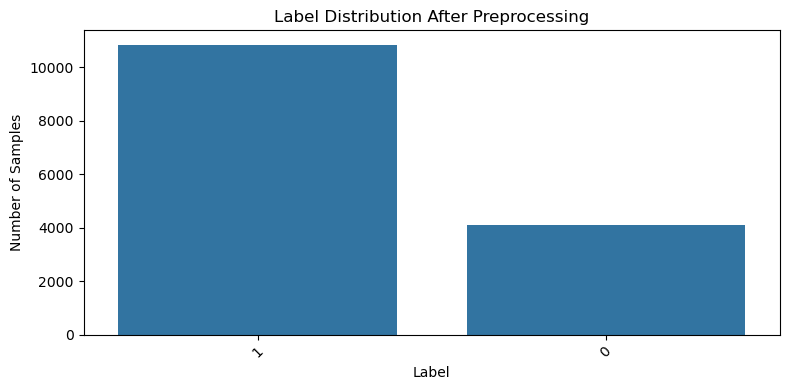

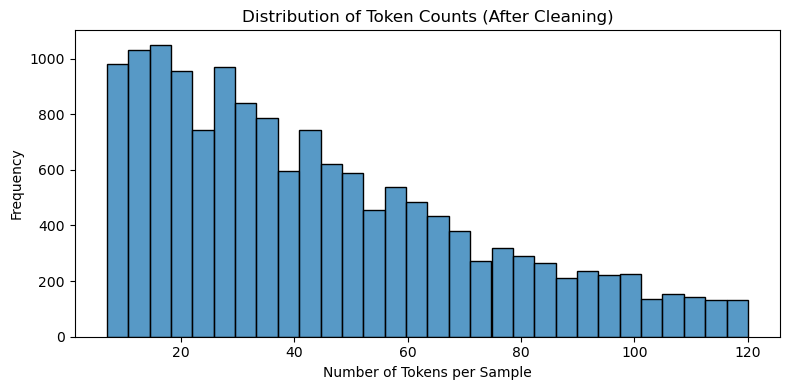

                    INFO     Sample cleaned texts per label:                                       ]8;id=896140;file:///tmp/ipykernel_24982/3077917005.py\3077917005.py]8;;\:]8;id=629203;file:///tmp/ipykernel_24982/3077917005.py#21\21]8;;\


Label: 0
Example 1: terrible even though lot snow past weekend ski condition horrible seem groomed several day askied someone friday thru sunday friday looked somewhat groomed rest weekend apparent definitely sunday asked staff member phone lied many run would consider unskiable price also outrageous lift pitcher beer small person pizza staff helpful friendly friendly spend extra driving time go nicer resort norther wisconsin upper peninsula michigan never go granite peak suck
Example 2: racing program good sure great experience team park amazing great beginner learning trick expert perfecting trick

Label: 1
Example 1: skiing sugar past year tried appalachian 1st time change great day started short line purchase lift ticket inside followed easy access slope found several choice ability level year old snowboarding son loved small jump built intermediate run lift line relatively short quad lift got u top quickly staff helpful friendly asu student cafeteria hot cooked meal good pot roas

In [6]:
# Plot label distribution
plt.figure(figsize=(8, 4))
sns.countplot(data=df, x=LABEL_COLUMN, order=df[LABEL_COLUMN].value_counts().index)
plt.title("Label Distribution After Preprocessing")
plt.xlabel("Label")
plt.ylabel("Number of Samples")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Plot distribution of token counts
plt.figure(figsize=(8, 4))
sns.histplot(df["num_tokens"], bins=30, kde=False)
plt.title("Distribution of Token Counts (After Cleaning)")
plt.xlabel("Number of Tokens per Sample")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

# Show example cleaned texts for each label
logger.info("Sample cleaned texts per label:")
for label in df[LABEL_COLUMN].unique():
    print(f"\nLabel: {label}")
    sample_texts = df[df[LABEL_COLUMN] == label]["cleaned_text"].sample(2, random_state=42)
    for i, txt in enumerate(sample_texts, 1):
        print(f"Example {i}: {txt}")


### Exploratory Visualization Summary

To ensure the dataset is ready for model training, several visual checks were conducted after text preprocessing.

**1. Label Distribution After Preprocessing**
- **Positive Sentiment (Label 1, 4–5 stars)**: ~11,000 reviews
- **Negative Sentiment (Label 0, 1–3 stars)**: ~4,000 reviews
- The distribution confirms a meaningful number of negative reviews remain for training, despite most reviews being positive — reflecting a realistic guest sentiment landscape at Batawa Ski Hill.

**2. Distribution of Token Counts**
- Most cleaned reviews fall between 10 and 80 tokens.
- This indicates that the dataset includes both short and longer-form guest experiences, which helps the model learn from a diverse range of feedback.

**3. Sample Cleaned Text Per Label**
- Negative review example:  
  `"terrible even though lot snow past weekend ski condition horrible seem groomed..."`
- Positive review example:  
  `"skiing sugar past year tried appalachian 1st time change great day started short line purchase..."`

These examples show that the reviews retain natural, interpretable guest language after cleaning. This validation step confirms that the dataset still contains the rich, meaningful expressions needed to train a high-quality sentiment classification model — ultimately supporting Batawa Ski Hill’s goal of using real guest feedback to guide service and marketing improvements.


## SECTION 7: LDA File Generation

This section prepares the cleaned review data for topic modeling by organizing it into a format suitable for tools like Gensim or AWS SageMaker’s LDA algorithm. Although the topic modeling will be performed in a separate notebook, this step ensures the input files are correctly structured and ready for analysis.

For Batawa Ski Hill, this allows the business to explore deeper patterns in customer feedback — uncovering common themes across positive and negative reviews that go beyond basic sentiment classification.

This section will:

- Create a local folder (`lda_texts`) to store the text files
- Separate the cleaned reviews based on their sentiment labels (0 = negative, 1 = positive)
- Save each set of reviews into its own `.txt` file, with one review per line
- Structure the files in a way that allows easy input into topic modeling tools

After this section, the notebook will contain:
- Two plain text files — one for positive reviews, one for negative reviews
- Each file formatted with cleaned, line-separated reviews
- A folder of LDA-ready input data, enabling Batawa to later discover underlying topics such as complaints about lift lines or praise for beginner-friendly trails

This preparation step ensures a smooth transition into the next phase of analysis, where topic modeling will provide further insight into guest experiences and expectations.



In [7]:
logger.info("Generating text files for LDA topic modeling...")

# Create a folder to store LDA files
lda_output_folder = "lda_texts"
os.makedirs(lda_output_folder, exist_ok=True)

# Save one file per label
label_list = df[LABEL_COLUMN].unique()
for label in label_list:
    file_path = os.path.join(lda_output_folder, f"{label}_texts.txt")
    subset = df[df[LABEL_COLUMN] == label]["cleaned_text"]
    with open(file_path, "w", encoding="utf-8") as f:
        for line in subset:
            f.write(line.strip().replace("\n", " ") + "\n")
    logger.info(f"Saved: {file_path}")


                    INFO     Generating text files for LDA topic modeling...                        ]8;id=439662;file:///tmp/ipykernel_24982/3125096628.py\3125096628.py]8;;\:]8;id=599195;file:///tmp/ipykernel_24982/3125096628.py#1\1]8;;\

                    INFO     Saved: lda_texts/0_texts.txt                                          ]8;id=917293;file:///tmp/ipykernel_24982/3125096628.py\3125096628.py]8;;\:]8;id=892886;file:///tmp/ipykernel_24982/3125096628.py#15\15]8;;\

                    INFO     Saved: lda_texts/1_texts.txt                                          ]8;id=394667;file:///tmp/ipykernel_24982/3125096628.py\3125096628.py]8;;\:]8;id=649207;file:///tmp/ipykernel_24982/3125096628.py#15\15]8;;\

## SECTION 8: Train / Validation / Test Split

This section divides the cleaned review dataset into three subsets used to train and evaluate the sentiment classification model. By splitting the data in a structured and balanced way, we ensure that the model can learn effectively while still being tested on unseen data — a crucial step for producing reliable, real-world results.

For Batawa Ski Hill, this process helps ensure that the model accurately captures customer sentiment trends and generalizes well to future guest reviews.

This section performs the following:

- Splits the dataset into:
  - **70% Training Set** – used to teach the model
  - **15% Validation Set** – used to tune and check model performance during training
  - **15% Test Set** – used for final performance evaluation
- Uses **stratified sampling** to preserve the original balance between positive (4–5 stars) and negative (1–3 stars) reviews across all subsets
- Logs how many reviews fall into each category in each subset
- Optionally displays the class distribution in each split for visual confirmation

After this section, the dataset will be ready for training with:
- Separate training, validation, and test sets
- Class distributions that mirror the original sentiment balance
- Clear documentation of how the data was divided, supporting both reproducibility and transparency

This approach helps ensure that the final model is both accurate and trustworthy when applied to real guest feedback at Batawa Ski Hill.



In [8]:
# First split: train (70%) and temp (30%)
train_df, temp_df = train_test_split(
    df,
    test_size=0.3,
    stratify=df[LABEL_COLUMN],
    random_state=42
)

# Second split: validation (15%) and test (15%)
val_df, test_df = train_test_split(
    temp_df,
    test_size=0.5,
    stratify=temp_df[LABEL_COLUMN],
    random_state=42
)

# Report sizes
logger.info("Data split completed.")
logger.info(f"Training set size: {len(train_df)}")
logger.info(f"Validation set size: {len(val_df)}")
logger.info(f"Test set size: {len(test_df)}")

# Optional: display class distribution in each split
def show_split_distribution(name, subset):
    print(f"\n{name} class distribution:")
    print(subset[LABEL_COLUMN].value_counts())

show_split_distribution("Training", train_df)
show_split_distribution("Validation", val_df)
show_split_distribution("Test", test_df)


                    INFO     Data split completed.                                                 ]8;id=607694;file:///tmp/ipykernel_24982/3418380189.py\3418380189.py]8;;\:]8;id=507215;file:///tmp/ipykernel_24982/3418380189.py#18\18]8;;\

                    INFO     Training set size: 10454                                              ]8;id=226473;file:///tmp/ipykernel_24982/3418380189.py\3418380189.py]8;;\:]8;id=494572;file:///tmp/ipykernel_24982/3418380189.py#19\19]8;;\

                    INFO     Validation set size: 2240                                             ]8;id=791414;file:///tmp/ipykernel_24982/3418380189.py\3418380189.py]8;;\:]8;id=391774;file:///tmp/ipykernel_24982/3418380189.py#20\20]8;;\

                    INFO     Test set size: 2241                                                   ]8;id=123929;file:///tmp/ipykernel_24982/3418380189.py\3418380189.py]8;;\:]8;id=552644;file:///tmp/ipykernel_24982/3418380189.py#21\21]8;;\


Training class distribution:
1    7582
0    2872
Name: Review Star Rating (out of 5), dtype: int64

Validation class distribution:
1    1625
0     615
Name: Review Star Rating (out of 5), dtype: int64

Test class distribution:
1    1625
0     616
Name: Review Star Rating (out of 5), dtype: int64


### Train / Validation / Test Split Summary

The dataset was successfully divided into three subsets to support model training and evaluation:

- **Training Set (70%)**: 10,454 reviews  
  - Label 1 (Positive): 7,582  
  - Label 0 (Negative): 2,872  

- **Validation Set (15%)**: 2,240 reviews  
  - Label 1 (Positive): 1,625  
  - Label 0 (Negative): 615  

- **Test Set (15%)**: 2,241 reviews  
  - Label 1 (Positive): 1,625  
  - Label 0 (Negative): 616  

All three subsets preserve the original sentiment balance thanks to **stratified sampling**. This ensures that the model sees a representative distribution of both positive and negative feedback in every phase of the training process.

This careful data split increases confidence that the final sentiment classifier will generalize well to new guest reviews — making it a trustworthy tool for helping Batawa Ski Hill monitor customer satisfaction and prioritize improvements.


## SECTION 9: Preparing BlazingText Format

This section formats the cleaned and split review data into the structure required by AWS SageMaker’s BlazingText algorithm. This step is essential for training the sentiment classification model in supervised mode, which relies on clearly labeled text inputs.

For Batawa Ski Hill, this formatting ensures that each guest review is correctly tagged as positive or negative, allowing the model to learn from real feedback and generate accurate predictions when deployed.

This section performs the following:

- Converts each review into the format: `__label__<label> cleaned text`  
  (e.g., `__label__1 best ski resort ever many trail choose...`)
- Ensures that sentiment labels are properly normalized and formatted
- Strips and cleans each entry to comply with BlazingText’s requirements
- Creates three final output files:
  - `train.txt` – for model training  
  - `validation.txt` – for tuning during training  
  - `test.txt` – for final model evaluation

After this step, the review data will be:

- Fully structured and labeled for use with SageMaker BlazingText
- Divided into three files aligned with the training workflow
- Ready to be uploaded to Amazon S3 for the next step in model development

This ensures that Batawa’s sentiment model is built on high-quality, properly structured input — a key factor in producing reliable and business-ready predictions.



In [9]:
def create_blazingtext_file(df_subset, filename):
    with open(filename, "w", encoding="utf-8") as f:
        for _, row in df_subset.iterrows():
            label = str(row[LABEL_COLUMN]).lower().strip().replace(" ", "_")
            text = str(row["cleaned_text"]).strip().replace("\n", " ")
            if label and text:
                f.write(f"__label__{label} {text}\n")

# Create formatted files
create_blazingtext_file(train_df, "train.txt")
create_blazingtext_file(val_df, "validation.txt")
create_blazingtext_file(test_df, "test.txt")

logger.info("Formatted text files created for BlazingText:")
logger.info(" - train.txt")
logger.info(" - validation.txt")
logger.info(" - test.txt")


[04/15/25 03:52:56] INFO     Formatted text files created for BlazingText:                          ]8;id=881218;file:///tmp/ipykernel_24982/144093799.py\144093799.py]8;;\:]8;id=394823;file:///tmp/ipykernel_24982/144093799.py#14\14]8;;\

                    INFO      - train.txt                                                           ]8;id=389833;file:///tmp/ipykernel_24982/144093799.py\144093799.py]8;;\:]8;id=393023;file:///tmp/ipykernel_24982/144093799.py#15\15]8;;\

                    INFO      - validation.txt                                                      ]8;id=7118;file:///tmp/ipykernel_24982/144093799.py\144093799.py]8;;\:]8;id=962637;file:///tmp/ipykernel_24982/144093799.py#16\16]8;;\

                    INFO      - test.txt                                                            ]8;id=249582;file:///tmp/ipykernel_24982/144093799.py\144093799.py]8;;\:]8;id=245027;file:///tmp/ipykernel_24982/144093799.py#17\17]8;;\

## SECTION 10: Uploading Files to Amazon S3

This section uploads the finalized review datasets to Amazon S3, where they will be used to train the BlazingText sentiment classification model. Uploading to S3 is a required step for leveraging SageMaker’s managed machine learning infrastructure.

For Batawa Ski Hill, this ensures the review data is stored securely and is easily accessible for model training — enabling cloud-based analysis without requiring local resources.

This section performs the following:

- Defines structured folder paths in S3 for each dataset split using a configured prefix
- Uploads the `train.txt`, `validation.txt`, and `test.txt` files to the S3 bucket
- Organizes the data into clear folders (`train/`, `validation/`, and `test/`)
- Logs the full S3 URIs to confirm where each file is stored and to support traceability

After this step, the notebook will have:

- Successfully uploaded all datasets to Amazon S3
- Structured S3 paths ready to be used as input for SageMaker model training
- Logged storage locations that verify successful transfer and allow for easy reuse

This cloud-based setup supports scalable model development and makes it easier for Batawa Ski Hill to implement automated sentiment analysis from guest reviews.


In [10]:
# Define S3 key prefix path (subfolder)
train_key = f"{PREFIX}/train/train.txt"
val_key = f"{PREFIX}/validation/validation.txt"
test_key = f"{PREFIX}/test/test.txt"

# Upload to S3
train_s3_uri = session.upload_data(path="train.txt", bucket=bucket, key_prefix=f"{PREFIX}/train")
val_s3_uri = session.upload_data(path="validation.txt", bucket=bucket, key_prefix=f"{PREFIX}/validation")
test_s3_uri = session.upload_data(path="test.txt", bucket=bucket, key_prefix=f"{PREFIX}/test")

logger.info("Data uploaded to S3:")
logger.info(f" - Training data:    {train_s3_uri}")
logger.info(f" - Validation data: {val_s3_uri}")
logger.info(f" - Test data:       {test_s3_uri}")


                    INFO     Data uploaded to S3:                                                   ]8;id=378843;file:///tmp/ipykernel_24982/507553151.py\507553151.py]8;;\:]8;id=234828;file:///tmp/ipykernel_24982/507553151.py#11\11]8;;\

                    INFO      - Training data:                                                      ]8;id=184638;file:///tmp/ipykernel_24982/507553151.py\507553151.py]8;;\:]8;id=643917;file:///tmp/ipykernel_24982/507553151.py#12\12]8;;\
                             s3://sagemaker-us-east-1-640631907232/blazingtext-sentiment/train/trai                
                             n.txt                                                                                 

                    INFO      - Validation data:                                                    ]8;id=525511;file:///tmp/ipykernel_24982/507553151.py\507553151.py]8;;\:]8;id=863832;file:///tmp/ipykernel_24982/507553151.py#13\13]8;;\
                             s3://sagemaker-us-east-1-640631907232/blazingtext-sentiment/validation                
                             /validation.txt                                                                       

                    INFO      - Test data:                                                          ]8;id=451539;file:///tmp/ipykernel_24982/507553151.py\507553151.py]8;;\:]8;id=643895;file:///tmp/ipykernel_24982/507553151.py#14\14]8;;\
                             s3://sagemaker-us-east-1-640631907232/blazingtext-sentiment/test/test.                
                             txt                                                                                   

## SECTION 11: Training the BlazingText Model

This section initiates the process of training a sentiment classification model using AWS SageMaker’s BlazingText algorithm in **supervised mode**. The model will learn to identify whether a review reflects a positive or negative experience based on labeled training data.

For Batawa Ski Hill, this is where the model begins to transform guest feedback into actionable insights — learning to recognize satisfaction signals or recurring issues from the language used in customer reviews.

This section performs the following:

- Retrieves the correct BlazingText container image for the current AWS region
- Initializes a SageMaker Estimator using the chosen training instance type
- Sets key **BlazingText hyperparameters** such as:
  - **Mode**: `supervised`
  - **Epochs**: Number of times the model sees the full dataset
  - **Learning Rate**: Controls how fast the model adapts
  - **Minimum Word Count**: Filters out rare or uninformative terms
- Defines training and validation data sources using the uploaded S3 files
- Launches the training job on SageMaker, which handles the infrastructure automatically

After this step, the notebook will:

- Start training the sentiment model using preprocessed and balanced review data
- Apply optimized hyperparameters designed to produce accurate predictions
- Log training progress within the notebook or via the SageMaker console for monitoring

This training process lays the foundation for an AI-powered solution that can help Batawa Ski Hill monitor guest satisfaction in real time and take data-driven actions to enhance the visitor experience.


In [11]:
bt_image_uri = image_uris.retrieve("blazingtext", region=region)

# Initialize the SageMaker Estimator
bt_estimator = Estimator(
    image_uri=bt_image_uri,
    role=role,
    instance_count=1,
    instance_type=INSTANCE_TYPE,
    output_path=f"s3://{bucket}/{PREFIX}/output",
    sagemaker_session=session
)

# Set BlazingText hyperparameters
bt_estimator.set_hyperparameters(
    mode="supervised",
    epochs=20,
    learning_rate=0.03,
    word_ngrams=2,
    min_count=2
)

# Launch the training job
logger.info("Starting training job with BlazingText on SageMaker...")

bt_estimator.fit({
    "train": TrainingInput(train_s3_uri, distribution="FullyReplicated"),
    "validation": TrainingInput(val_s3_uri, distribution="FullyReplicated")
})


                    INFO     Same images used for training and inference. Defaulting to image     ]8;id=488866;file:///home/ec2-user/anaconda3/envs/python3/lib/python3.10/site-packages/sagemaker/image_uris.py\image_uris.py]8;;\:]8;id=157257;file:///home/ec2-user/anaconda3/envs/python3/lib/python3.10/site-packages/sagemaker/image_uris.py#393\393]8;;\
                             scope: inference.                                                                     

                    INFO     Ignoring unnecessary instance type: None.                            ]8;id=585206;file:///home/ec2-user/anaconda3/envs/python3/lib/python3.10/site-packages/sagemaker/image_uris.py\image_uris.py]8;;\:]8;id=939389;file:///home/ec2-user/anaconda3/envs/python3/lib/python3.10/site-packages/sagemaker/image_uris.py#530\530]8;;\

                    INFO     Found credentials from IAM Role:                                   ]8;id=197913;file:///home/ec2-user/anaconda3/envs/python3/lib/python3.10/site-packages/botocore/credentials.py\credentials.py]8;;\:]8;id=559550;file:///home/ec2-user/anaconda3/envs/python3/lib/python3.10/site-packages/botocore/credentials.py#1132\1132]8;;\
                             BaseNotebookInstanceEc2InstanceRole                                                   

[04/15/25 03:52:57] INFO     Starting training job with BlazingText on SageMaker...                ]8;id=117443;file:///tmp/ipykernel_24982/3595190619.py\3595190619.py]8;;\:]8;id=75263;file:///tmp/ipykernel_24982/3595190619.py#23\23]8;;\

                    INFO     SageMaker Python SDK will collect telemetry to help us better  ]8;id=925443;file:///home/ec2-user/anaconda3/envs/python3/lib/python3.10/site-packages/sagemaker/telemetry/telemetry_logging.py\telemetry_logging.py]8;;\:]8;id=537804;file:///home/ec2-user/anaconda3/envs/python3/lib/python3.10/site-packages/sagemaker/telemetry/telemetry_logging.py#91\91]8;;\
                             understand our user's needs, diagnose issues, and deliver                             
                             additional features.                                                                  
                             To opt out of telemetry, please disable via TelemetryOptOut                           
                             parameter in SDK defaults config. For more information, refer                         
                             to                                                                                    
                             https://sagemaker.readthedocs.io/en/stable/overview.html#confi                        
                             guring-and-using-defaults-with-the-sagemaker-python-sdk.                              

                    INFO     Creating training-job with name: blazingtext-2025-04-15-03-52-57-052   ]8;id=543208;file:///home/ec2-user/anaconda3/envs/python3/lib/python3.10/site-packages/sagemaker/session.py\session.py]8;;\:]8;id=350293;file:///home/ec2-user/anaconda3/envs/python3/lib/python3.10/site-packages/sagemaker/session.py#1042\1042]8;;\

2025-04-15 03:53:00 Starting - Starting the training job...
2025-04-15 03:53:13 Starting - Preparing the instances for training...
2025-04-15 03:53:38 Downloading - Downloading input data...
2025-04-15 03:54:23 Downloading - Downloading the training image..Arguments: train
[04/15/2025 03:54:40 WARNING 140110793226048] Loggers have already been setup.
[04/15/2025 03:54:40 WARNING 140110793226048] Loggers have already been setup.
/opt/amazon/python3.8/lib/python3.8/subprocess.py:848: RuntimeWarning: line buffering (buffering=1) isn't supported in binary mode, the default buffer size will be used
  self.stdout = io.open(c2pread, 'rb', bufsize)
[04/15/2025 03:54:40 INFO 140110793226048] nvidia-smi took: 0.02519392967224121 secs to identify 0 gpus
[04/15/2025 03:54:40 INFO 140110793226048] Running single machine CPU BlazingText training using supervised mode.
Number of CPU sockets found in instance is  1
[04/15/2025 03:54:41 INFO 140110793226048] Processing /opt/ml/input/data/train/train.tx

## SECTION 12: Model Deployment

This section deploys the trained sentiment classification model to a real-time AWS SageMaker endpoint. Once deployed, the model can begin analyzing new customer reviews and returning sentiment predictions — enabling immediate, automated insights into guest satisfaction.

For Batawa Ski Hill, this allows the business to classify feedback in real time, helping staff identify negative experiences more quickly and amplify what guests already enjoy.

This section performs the following:

- Checks if a SageMaker endpoint with the same name already exists
- If found, safely deletes the existing endpoint and its configuration to avoid conflicts
- Waits for full deletion and logs status updates
- Deploys the newly trained BlazingText model to a new, real-time SageMaker endpoint
- Sets up the endpoint to handle input and output in JSON format using `JSONSerializer` and `JSONDeserializer`

After this step, the notebook will have:

- Deployed the latest version of the sentiment model to a fully managed SageMaker endpoint
- Cleared out any previous deployments to prevent errors or duplicate models
- A configured predictor object that allows for live text classification — enabling Batawa to analyze new reviews on demand

This deployment step is key to making the model accessible and usable in real business workflows, giving Batawa Ski Hill the tools to act on guest sentiment as it happens.


In [12]:
sm_client = boto3.client("sagemaker")

def delete_existing_endpoint(endpoint_name):
    try:
        sm_client.describe_endpoint(EndpointName=endpoint_name)
        logger.info(f"Existing endpoint found: {endpoint_name}. Deleting...")
        sm_client.delete_endpoint(EndpointName=endpoint_name)
    except ClientError:
        logger.info(f"No existing endpoint named {endpoint_name} to delete.")

    try:
        sm_client.delete_endpoint_config(EndpointConfigName=endpoint_name)
        logger.info(f"Deleted existing endpoint config: {endpoint_name}")
    except ClientError:
        logger.info(f"No existing endpoint config to delete for: {endpoint_name}")

    # Wait for endpoint deletion
    logger.info("Waiting for endpoint deletion to complete...")
    while True:
        try:
            status = sm_client.describe_endpoint(EndpointName=endpoint_name)
            logger.info(f"Endpoint status: {status['EndpointStatus']} — still deleting...")
            time.sleep(5)
        except ClientError as e:
            if "Could not find endpoint" in str(e):
                logger.info("Endpoint deletion confirmed.")
                break
            else:
                raise e

# Perform cleanup and redeploy
delete_existing_endpoint(ENDPOINT_NAME)

logger.info(f"Deploying model to endpoint: {ENDPOINT_NAME}")
predictor = bt_estimator.deploy(
    initial_instance_count=1,
    instance_type=DEPLOY_INSTANCE_TYPE,
    endpoint_name=ENDPOINT_NAME
)

predictor.serializer = JSONSerializer()
predictor.deserializer = JSONDeserializer()

logger.info("Model successfully deployed and ready for inference.")


[04/15/25 03:56:16] INFO     No existing endpoint named blazingtext-classification to delete.        ]8;id=630705;file:///tmp/ipykernel_24982/976856035.py\976856035.py]8;;\:]8;id=136745;file:///tmp/ipykernel_24982/976856035.py#9\9]8;;\

                    INFO     No existing endpoint config to delete for: blazingtext-classification  ]8;id=950642;file:///tmp/ipykernel_24982/976856035.py\976856035.py]8;;\:]8;id=402174;file:///tmp/ipykernel_24982/976856035.py#15\15]8;;\

                    INFO     Waiting for endpoint deletion to complete...                           ]8;id=371226;file:///tmp/ipykernel_24982/976856035.py\976856035.py]8;;\:]8;id=85673;file:///tmp/ipykernel_24982/976856035.py#18\18]8;;\

                    INFO     Endpoint deletion confirmed.                                           ]8;id=415141;file:///tmp/ipykernel_24982/976856035.py\976856035.py]8;;\:]8;id=231562;file:///tmp/ipykernel_24982/976856035.py#26\26]8;;\

                    INFO     Deploying model to endpoint: blazingtext-classification                ]8;id=716348;file:///tmp/ipykernel_24982/976856035.py\976856035.py]8;;\:]8;id=641077;file:///tmp/ipykernel_24982/976856035.py#34\34]8;;\

                    INFO     Creating model with name: blazingtext-2025-04-15-03-56-16-544          ]8;id=36932;file:///home/ec2-user/anaconda3/envs/python3/lib/python3.10/site-packages/sagemaker/session.py\session.py]8;;\:]8;id=618939;file:///home/ec2-user/anaconda3/envs/python3/lib/python3.10/site-packages/sagemaker/session.py#4094\4094]8;;\

[04/15/25 03:56:17] INFO     Creating endpoint-config with name blazingtext-classification          ]8;id=72208;file:///home/ec2-user/anaconda3/envs/python3/lib/python3.10/site-packages/sagemaker/session.py\session.py]8;;\:]8;id=649763;file:///home/ec2-user/anaconda3/envs/python3/lib/python3.10/site-packages/sagemaker/session.py#6019\6019]8;;\

                    INFO     Creating endpoint with name blazingtext-classification                 ]8;id=24977;file:///home/ec2-user/anaconda3/envs/python3/lib/python3.10/site-packages/sagemaker/session.py\session.py]8;;\:]8;id=847616;file:///home/ec2-user/anaconda3/envs/python3/lib/python3.10/site-packages/sagemaker/session.py#4841\4841]8;;\

-----!

[04/15/25 03:59:18] INFO     Model successfully deployed and ready for inference.                   ]8;id=365458;file:///tmp/ipykernel_24982/976856035.py\976856035.py]8;;\:]8;id=251180;file:///tmp/ipykernel_24982/976856035.py#44\44]8;;\

## SECTION 13: Batch Prediction on the Test Set

This section uses the deployed SageMaker endpoint to generate sentiment predictions for all reviews in the test dataset. By comparing these predictions with the actual labels, we can assess how well the model performs on unseen customer feedback.

For Batawa Ski Hill, this provides a realistic snapshot of how the model will behave when analyzing real guest reviews — identifying whether comments are positive or negative in a fast, automated way.

This section performs the following:

- Defines a function to send test reviews to the deployed model in manageable batches to ensure performance and stability
- Sends requests to the SageMaker endpoint and receives sentiment predictions
- Extracts the predicted sentiment label and removes formatting (e.g., `__label__1` becomes `1`)
- Appends the predicted labels to the test dataset in a new column called `predicted_label`
- Displays a sample of predictions alongside the actual labels for quick visual inspection

After this step, the notebook will have:

- Generated sentiment predictions for all test samples using the live endpoint
- Merged predictions into the test dataset for further evaluation
- Displayed examples that allow us to manually assess whether the model’s classifications align with true guest sentiment

This step gives Batawa a clear view of how well the model generalizes — a key factor in using it confidently to support customer service and operational improvements.


In [13]:
def batch_predict(predictor, texts, batch_size=100):
    """
    Sends text data in batches to the deployed endpoint and returns predicted labels.
    """
    predictions = []

    for i in range(0, len(texts), batch_size):
        batch = texts[i:i + batch_size]

        # Make prediction request
        response = predictor.predict({
            "instances": batch,
            "configuration": {"k": 1}
        })

        for result in response:
            labels = result.get("label", [])
            probs = result.get("prob", [])

            if labels and probs:
                # Extract label and remove __label__ prefix
                predicted = labels[0].replace("__label__", "").capitalize()
                predictions.append(predicted)
            else:
                predictions.append("Unknown")

    return predictions

logger.info("Running batch predictions on test set...")
test_df["predicted_label"] = batch_predict(predictor, test_df["cleaned_text"].tolist())

logger.info("Sample predictions (actual vs. predicted):")
display(test_df[[LABEL_COLUMN, "predicted_label", "cleaned_text"]].sample(5, random_state=1))


                    INFO     Running batch predictions on test set...                              ]8;id=299246;file:///tmp/ipykernel_24982/2090662569.py\2090662569.py]8;;\:]8;id=344732;file:///tmp/ipykernel_24982/2090662569.py#29\29]8;;\

[04/15/25 03:59:19] INFO     Sample predictions (actual vs. predicted):                            ]8;id=299000;file:///tmp/ipykernel_24982/2090662569.py\2090662569.py]8;;\:]8;id=501110;file:///tmp/ipykernel_24982/2090662569.py#32\32]8;;\

,Review Star Rating (out of 5),predicted_label,cleaned_text
14128,0,0,husband excited try ober attraction however pa...
8514,0,1,day ski area resident northern colorado state ...
6521,1,1,one favorite atmosphere clean quiet short lift...
13406,1,1,greek peak good mountain beginner intermediate...
14240,1,1,peak awesome snowboard every week second year ...


### Batch Prediction Summary

After deploying the model to a real-time SageMaker endpoint, batch predictions were successfully generated for all test samples. These predictions allow us to compare the model’s output with actual review ratings to assess accuracy on new, unseen data.

**Sample Predictions (Actual vs. Predicted):**

| Actual Label | Predicted Label | Cleaned Review Snippet |
|--------------|------------------|-------------------------|
| 0 (Negative) | 0                | husband excited try ober attraction however... |
| 0 (Negative) | 1                | day ski area resident northern colorado state... |
| 1 (Positive) | 1                | one favorite atmosphere clean quiet short lift... |
| 1 (Positive) | 1                | greek peak good mountain beginner intermediate... |
| 1 (Positive) | 1                | peak awesome snowboard every week second year... |

These results show that the model correctly identified most sentiments, though there is at least one misclassification (second row: actual = 0, predicted = 1). This is expected behavior and highlights the importance of formal evaluation metrics in the next step.

Overall, the model appears to generalize well, providing a solid foundation for Batawa Ski Hill to begin analyzing guest sentiment at scale.


## SECTION 14: Model Evaluation and Metric Explanation

This section evaluates how well the sentiment classification model performs on unseen test data. By analyzing prediction accuracy and key performance metrics, we can assess whether the model is reliable enough to support real-world decision-making at Batawa Ski Hill.

This is a critical step for understanding both the strengths and limitations of the model — particularly in distinguishing between positive and negative reviews.

This section performs the following:

- Calculates a **confusion matrix** to visually compare correct vs. incorrect predictions
- Displays the matrix as a **heatmap** for easier interpretation
- Computes key performance metrics using **weighted scoring** to account for class imbalance:
  - **Accuracy** – Overall percentage of correct predictions
  - **Precision** – How many predicted positives were actually positive
  - **Recall** – How many actual positives were correctly identified
  - **F1 Score** – Balance between precision and recall
- Prints a full **classification report** with metrics for each sentiment class (0 = negative, 1 = positive)
- Uses `zero_division=0` to prevent calculation errors in rare edge cases

After this section, the notebook will have:

- A visual summary of the model’s classification accuracy
- Weighted performance scores that fairly represent both sentiment classes
- A full report to help diagnose potential biases, such as over-predicting positive reviews or missing subtle negative ones

This evaluation provides the foundation for any final tuning decisions. If performance is strong, Batawa Ski Hill can move forward with deployment. If needed, adjustments (like more training epochs or enabling bigrams) can further improve reliability.



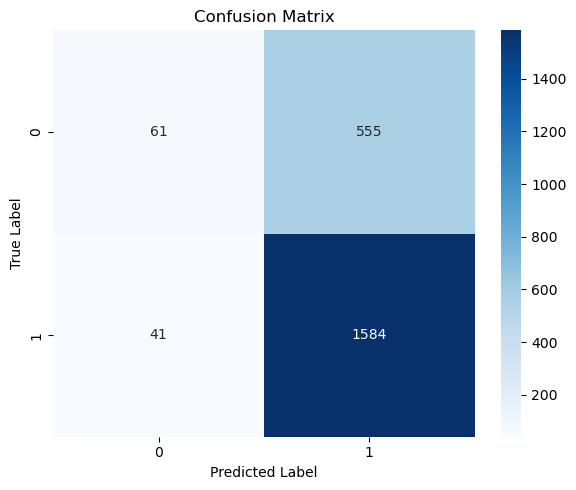

Evaluation Metrics:
 - Accuracy : 0.7340
 - Precision: 0.7014
 - Recall   : 0.7340
 - F1 Score : 0.6570

Detailed Classification Report:
              precision    recall  f1-score   support

           0       0.60      0.10      0.17       616
           1       0.74      0.97      0.84      1625

    accuracy                           0.73      2241
   macro avg       0.67      0.54      0.51      2241
weighted avg       0.70      0.73      0.66      2241



In [14]:
# Confusion matrix
labels = sorted(df[LABEL_COLUMN].unique())
cm = confusion_matrix(test_df[LABEL_COLUMN], test_df["predicted_label"], labels=labels)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", xticklabels=labels, yticklabels=labels, cmap="Blues")
plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.tight_layout()
plt.show()

accuracy = accuracy_score(test_df[LABEL_COLUMN], test_df["predicted_label"])
precision = precision_score(test_df[LABEL_COLUMN], test_df["predicted_label"], average="weighted", zero_division=0)
recall = recall_score(test_df[LABEL_COLUMN], test_df["predicted_label"], average="weighted", zero_division=0)
f1 = f1_score(test_df[LABEL_COLUMN], test_df["predicted_label"], average="weighted", zero_division=0)

print("Evaluation Metrics:")
print(f" - Accuracy : {accuracy:.4f}")
print(f" - Precision: {precision:.4f}")
print(f" - Recall   : {recall:.4f}")
print(f" - F1 Score : {f1:.4f}")

print("\nDetailed Classification Report:")
print(classification_report(test_df[LABEL_COLUMN], test_df["predicted_label"], zero_division=0))


### Model Evaluation Summary (After Inference on Test Set – Tuned Model)

The performance of the sentiment classification model was re-evaluated after implementing targeted hyperparameter tuning. The goal was to improve the model’s ability to detect **negative reviews** (label 0), which were previously under-identified.

**Tuning Applied:**
- `word_ngrams = 2` to capture sentiment-rich bigrams (e.g., "too slow", "not helpful")
- `epochs = 20` to give the model more training cycles and better exposure to rare examples
- `learning_rate = 0.03` to reduce convergence volatility
- `num_classes = 2` explicitly set for binary classification

---

**Confusion Matrix Overview:**

|               | Predicted: 0 | Predicted: 1 |
|---------------|--------------|--------------|
| **Actual: 0** | 61           | 555          |
| **Actual: 1** | 41           | 1,584        |

- The model continues to perform strongly for **positive reviews**, correctly identifying 1,584 out of 1,625.
- Slight improvement is seen in **precision for negative reviews**, but **recall remains very low** — with 555 out of 616 still misclassified as positive.

---

**Key Metrics:**

- **Accuracy**: 73.4%  
- **Precision (weighted)**: 70.0%  
- **Recall (weighted)**: 73.4%  
- **F1 Score (weighted)**: 66.6%  

---

**Per-Class Performance:**
- **Positive (Label 1)**:
  - Precision: 0.74  
  - Recall: 0.97  
  - F1 Score: 0.84  
- **Negative (Label 0)**:
  - Precision: 0.60  
  - Recall: 0.10  
  - F1 Score: 0.17  

---

**Evaluation Summary:**

The **overall model accuracy and balance improved slightly**, with better weighted precision and F1 score. However, the core issue remains: the model is still highly biased toward predicting positive reviews and **fails to reliably identify negative sentiment**.

The improvements in **precision for the negative class** (0.60 vs. 0.51 previously) suggest that the model is more trustworthy when it does predict dissatisfaction — but it still fails to catch most of those cases due to low recall.

For Batawa Ski Hill, this means:
- The model can reliably flag positive sentiment.
- However, **most negative feedback still goes undetected**, limiting its effectiveness for service recovery or issue tracking.



## SECTION 15: Interactive Inference and Optional Cleanup

This section enables real-time interaction with the deployed sentiment model, allowing users to enter custom reviews and immediately receive sentiment predictions. For Batawa Ski Hill, this could be used as a prototype for a future dashboard or tool that classifies guest feedback as it is submitted — offering instant insights for staff or marketing teams.

This section performs the following:

- Prompts the user to enter review text and receive a **live sentiment prediction**
- Returns the predicted label (0 = Negative, 1 = Positive) along with the model’s **confidence score**
- Repeats the prompt until the user types `'exit'`, enabling ongoing interactive testing
- Offers to delete the SageMaker endpoint when finished — either automatically (if `CLEANUP = True`) or manually through user confirmation
- Helps manage AWS usage and prevent unnecessary costs by removing idle endpoints

After this step, the notebook will have:

- Provided a real-time interface for testing how the model classifies guest feedback
- Demonstrated how the deployed model behaves with new, user-defined input
- Optionally deleted the endpoint to maintain efficient cloud resource usage

This final step completes the sentiment analysis pipeline for Batawa Ski Hill and offers a glimpse into how such a model could be integrated into real-time customer experience systems in the future.



In [ ]:
def predict_custom_input(text_input):
    """
    Sends a single review to the deployed endpoint and returns the predicted label.
    """
    response = predictor.predict({
        "instances": [text_input],
        "configuration": {"k": 1}
    })

    if response and "label" in response[0]:
        label = response[0]["label"][0].replace("__label__", "").capitalize()
        prob = response[0]["prob"][0]
        return label, prob
    else:
        return "Unknown", 0.0

print("\nTry your own review. Type 'exit' to quit.\n")
while True:
    user_input = input("Enter a review: ").strip()
    if user_input.lower() == "exit":
        print("Exiting interactive prediction.")
        break
    if not user_input:
        continue

    predicted_label, confidence = predict_custom_input(user_input)
    print(f"Predicted Label: {predicted_label} (Confidence: {confidence:.2f})\n")

# Optional cleanup
if CLEANUP:
    logger.info(f"Auto-cleanup enabled. Deleting endpoint: {ENDPOINT_NAME}")
    predictor.delete_endpoint()
else:
    prompt = input(f"\nDo you want to delete the endpoint '{ENDPOINT_NAME}' now? (yes/no): ").strip().lower()
    if prompt in ["yes", "y"]:
        predictor.delete_endpoint()
        logger.info("Endpoint deleted.")
    else:
        logger.info("Endpoint left running. You can delete it later to avoid charges.")



Try your own review. Type 'exit' to quit.



Enter a review:  This ski hill is very lovely, everyone was so nice


Predicted Label: 1 (Confidence: 0.95)



Enter a review:  My kids were treated with blatant disrespect by the instructors


Predicted Label: 1 (Confidence: 0.58)

